# Bergers Equation

In [ ]:
# ============================================================
# X-SciAL Burgers PINN
# EXTREME LARGE-ERROR BASELINE (loss ~100–1000)
# 100 adaptive iterations
# ============================================================

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------------------------------------
# Domain
# ------------------------------------------------------------
x_min,x_max=-1,1
t_min,t_max=0,1
nu=0.01/np.pi
residual_scale=100

# ------------------------------------------------------------
# ULTRA WEAK PINN
# ------------------------------------------------------------
class PINN(nn.Module):
    def __init__(self,layers):
        super().__init__()
        self.net=nn.ModuleList()
        for i in range(len(layers)-1):
            self.net.append(nn.Linear(layers[i],layers[i+1]))
    def forward(self,x):
        for layer in self.net[:-1]:
            x=torch.tanh(layer(x))
        return self.net[-1](x)

# ------------------------------------------------------------
# Residual
# ------------------------------------------------------------
def burgers_residual(model,x,t):
    x.requires_grad_(True);t.requires_grad_(True)
    u=model(torch.cat([x,t],1))
    u_t=torch.autograd.grad(u,t,torch.ones_like(u),retain_graph=True,create_graph=True)[0]
    u_x=torch.autograd.grad(u,x,torch.ones_like(u),retain_graph=True,create_graph=True)[0]
    u_xx=torch.autograd.grad(u_x,x,torch.ones_like(u_x),retain_graph=True,create_graph=True)[0]
    return residual_scale*(u_t+u*u_x-nu*u_xx)

# ------------------------------------------------------------
# Collocation
# ------------------------------------------------------------
N_f=50
x_f_base=torch.rand(N_f,1)*(x_max-x_min)+x_min
t_f_base=torch.rand(N_f,1)*(t_max-t_min)+t_min
x_f_base,t_f_base=x_f_base.to(device),t_f_base.to(device)

def pinn_loss(model,x_f,t_f):
    return torch.mean(burgers_residual(model,x_f,t_f)**2)

# ------------------------------------------------------------
# Grid
# ------------------------------------------------------------
Nx,Nt=25,25
x=np.linspace(-1,1,Nx)
t=np.linspace(0,1,Nt)
X,T=np.meshgrid(x,t)

x_t=torch.tensor(X.reshape(-1,1),dtype=torch.float32).to(device)
t_t=torch.tensor(T.reshape(-1,1),dtype=torch.float32).to(device)

# ------------------------------------------------------------
# Uncertainty + attribution
# ------------------------------------------------------------
def compute_uncertainty(model,x,t,n=2):
    model.train()
    preds=[]
    with torch.no_grad():
        for _ in range(n):
            preds.append(model(torch.cat([x,t],1)))
    return torch.var(torch.stack(preds),0)

def compute_attr(model,x,t):
    model.eval()
    x.requires_grad_(True);t.requires_grad_(True)
    u=model(torch.cat([x,t],1))
    ux=torch.autograd.grad(u,x,torch.ones_like(u),retain_graph=True,create_graph=True)[0]
    ut=torch.autograd.grad(u,t,torch.ones_like(u),retain_graph=True,create_graph=True)[0]
    return torch.sqrt(ux**2+ut**2)

# ============================================================
# EXPERIMENT
# ============================================================
centers=[(float(i),float(i)) for i in range(0,11)]
loss_list=[]

for alpha,beta in centers:

    print(f"\nRunning alpha={alpha}, beta={beta}")

    model=PINN([2,4,1]).to(device)
    opt=torch.optim.Adam(model.parameters(),lr=1e-2)

    x_f=x_f_base.clone()
    t_f=t_f_base.clone()

    # weak baseline
    for epoch in range(20):
        opt.zero_grad()
        pinn_loss(model,x_f,t_f).backward()
        opt.step()

    # =====================================================
    # 🔥 100 ADAPTIVE ITERATIONS
    # =====================================================
    adaptive_iters=500

    for it in range(adaptive_iters):

        U=compute_uncertainty(model,x_t,t_t).cpu().numpy().reshape(Nt,Nx)
        A=compute_attr(model,x_t,t_t).cpu().detach().numpy().reshape(Nt,Nx)

        U_n=(U-U.min())/(U.max()-U.min()+1e-8)
        A_n=(A-A.min())/(A.max()-A.min()+1e-8)
        S=(U_n**alpha)*(A_n**beta)

        k=20
        idx=np.argsort(S.flatten())[::-1][:k]
        x_new=X.flatten()[idx][:,None]
        t_new=T.flatten()[idx][:,None]

        x_f=torch.cat([x_f,torch.tensor(x_new,dtype=torch.float32).to(device)])
        t_f=torch.cat([t_f,torch.tensor(t_new,dtype=torch.float32).to(device)])

        for _ in range(10):
            opt.zero_grad()
            pinn_loss(model,x_f,t_f).backward()
            opt.step()

        if it%10==0:
            print(f"Iter {it} Loss {pinn_loss(model,x_f,t_f).item():.4e}")

    L=pinn_loss(model,x_f,t_f).item()
    loss_list.append(L)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
plt.figure(figsize=(7,4))
plt.plot(loss_list,marker='o')
plt.title("Large Loss vs (alpha,beta) with 100 adaptive iterations")
plt.grid(True)
plt.show()


Running alpha=0.0, beta=0.0
Iter 0 Loss 1.3142e+00
Iter 10 Loss 9.5484e-02
Iter 20 Loss 4.2889e-02
Iter 30 Loss 2.4134e-02
Iter 40 Loss 1.4212e-02
Iter 50 Loss 8.5992e-03
Iter 60 Loss 5.4305e-03
Iter 70 Loss 3.7269e-03
Iter 80 Loss 2.8674e-03
Iter 90 Loss 2.4436e-03
Iter 100 Loss 2.2148e-03
Iter 110 Loss 2.0617e-03
Iter 120 Loss 1.9353e-03
Iter 130 Loss 1.8187e-03
Iter 140 Loss 1.7074e-03
Iter 150 Loss 1.6006e-03
Iter 160 Loss 1.4982e-03
Iter 170 Loss 1.4007e-03
Iter 180 Loss 1.3083e-03
Iter 190 Loss 1.2210e-03
Iter 200 Loss 1.1390e-03
Iter 210 Loss 1.0623e-03
Iter 220 Loss 9.9072e-04
Iter 230 Loss 9.2427e-04
Iter 240 Loss 8.6272e-04
Iter 250 Loss 8.0593e-04
Iter 260 Loss 7.5366e-04
Iter 270 Loss 7.0566e-04
Iter 280 Loss 6.6170e-04
Iter 290 Loss 6.2150e-04
Iter 300 Loss 5.8480e-04
Iter 310 Loss 5.5132e-04
Iter 320 Loss 5.2078e-04
Iter 330 Loss 4.9292e-04
Iter 340 Loss 4.6753e-04
Iter 350 Loss 4.4430e-04
Iter 360 Loss 4.2303e-04
Iter 370 Loss 4.0349e-04
Iter 380 Loss 3.8549e-04
Iter 39

KeyboardInterrupt: 

# Weakest Baseline

In [ ]:
# ============================================================
# X-SciAL Burgers PINN
# EXTREME WEAK BASELINE
# Repeated adaptive sampling until loss stabilizes
# ============================================================

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

torch.manual_seed(0)
np.random.seed(0)
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------------------------------------
# Domain
# ------------------------------------------------------------
x_min,x_max=-1,1
t_min,t_max=0,1
nu=0.01/np.pi

# ------------------------------------------------------------
# EXTREME WEAK PINN
# ------------------------------------------------------------
class PINN(nn.Module):
    def __init__(self,layers):
        super().__init__()
        self.net=nn.ModuleList()
        for i in range(len(layers)-1):
            self.net.append(nn.Linear(layers[i],layers[i+1]))
    def forward(self,x):
        for layer in self.net[:-1]:
            x=torch.tanh(layer(x))
        return self.net[-1](x)

# ------------------------------------------------------------
# Residual
# ------------------------------------------------------------
def burgers_residual(model,x,t):
    x.requires_grad_(True);t.requires_grad_(True)
    u=model(torch.cat([x,t],1))
    u_t=torch.autograd.grad(u,t,torch.ones_like(u),retain_graph=True,create_graph=True)[0]
    u_x=torch.autograd.grad(u,x,torch.ones_like(u),retain_graph=True,create_graph=True)[0]
    u_xx=torch.autograd.grad(u_x,x,torch.ones_like(u_x),retain_graph=True,create_graph=True)[0]
    return u_t+u*u_x-nu*u_xx

# ------------------------------------------------------------
# VERY FEW collocation points
# ------------------------------------------------------------
N_f=250
x_f_base=torch.rand(N_f,1)*(x_max-x_min)+x_min
t_f_base=torch.rand(N_f,1)*(t_max-t_min)+t_min
x_f_base,t_f_base=x_f_base.to(device),t_f_base.to(device)

def pinn_loss(model,x_f,t_f):
    return torch.mean(burgers_residual(model,x_f,t_f)**2)

# ------------------------------------------------------------
# Coarse grid for maps
# ------------------------------------------------------------
Nx,Nt=40,40
x=np.linspace(-1,1,Nx)
t=np.linspace(0,1,Nt)
X,T=np.meshgrid(x,t)

x_t=torch.tensor(X.reshape(-1,1),dtype=torch.float32).to(device)
t_t=torch.tensor(T.reshape(-1,1),dtype=torch.float32).to(device)

# ------------------------------------------------------------
# Uncertainty + attribution
# ------------------------------------------------------------
def compute_uncertainty(model,x,t,n=3):
    model.train()
    preds=[]
    with torch.no_grad():
        for _ in range(n):
            preds.append(model(torch.cat([x,t],1)))
    return torch.var(torch.stack(preds),0)

def compute_attr(model,x,t):
    model.eval()
    x.requires_grad_(True);t.requires_grad_(True)
    u=model(torch.cat([x,t],1))
    ux=torch.autograd.grad(u,x,torch.ones_like(u),retain_graph=True,create_graph=True)[0]
    ut=torch.autograd.grad(u,t,torch.ones_like(u),retain_graph=True,create_graph=True)[0]
    return torch.sqrt(ux**2+ut**2)

# ============================================================
# EXPERIMENT
# ============================================================
centers=[(float(i),float(i)) for i in range(0,21)]

loss_list=[]
alpha_list=[]
beta_list=[]

# stabilization parameters
tol=1e-10
max_iter=10

for alpha,beta in centers:

    print(f"\nRunning alpha={alpha}, beta={beta}")

    model=PINN([2,8,1]).to(device)
    opt=torch.optim.Adam(model.parameters(),lr=1e-3)

    x_f=x_f_base.clone()
    t_f=t_f_base.clone()

    # --- VERY weak baseline training ---
    for epoch in range(150):
        opt.zero_grad()
        pinn_loss(model,x_f,t_f).backward()
        opt.step()

    prev_loss=1e9

    # --- repeated adaptive sampling ---
    for it in range(max_iter):

        U=compute_uncertainty(model,x_t,t_t).cpu().numpy().reshape(Nt,Nx)
        A=compute_attr(model,x_t,t_t).cpu().detach().numpy().reshape(Nt,Nx)

        U_n=(U-U.min())/(U.max()-U.min()+1e-8)
        A_n=(A-A.min())/(A.max()-A.min()+1e-8)
        S=(U_n**alpha)*(A_n**beta)

        k=50
        idx=np.argsort(S.flatten())[::-1][:k]
        x_new=X.flatten()[idx][:,None]
        t_new=T.flatten()[idx][:,None]

        x_f=torch.cat([x_f,torch.tensor(x_new,dtype=torch.float32).to(device)])
        t_f=torch.cat([t_f,torch.tensor(t_new,dtype=torch.float32).to(device)])

        # retrain
        for _ in range(80):
            opt.zero_grad()
            pinn_loss(model,x_f,t_f).backward()
            opt.step()

        cur_loss=pinn_loss(model,x_f,t_f).item()
        print(f"Iter {it+1} Loss {cur_loss:.4e}")

        if abs(prev_loss-cur_loss)<tol:
            print("Loss stabilized")
            break

        prev_loss=cur_loss

    loss_list.append(cur_loss)
    alpha_list.append(alpha)
    beta_list.append(beta)

# ============================================================
# Plot
# ============================================================
plt.figure(figsize=(7,4))
plt.plot(range(len(loss_list)),loss_list,marker='o')
plt.title("Stabilized Loss vs (alpha,beta)")
plt.grid(True)
plt.show()

# ============================================================
# Surrogate surface
# ============================================================
A=np.array(alpha_list)
B=np.array(beta_list)
L=np.array(loss_list)

X_design=np.vstack([np.ones_like(A),A,B,A*B,A**2,B**2]).T
theta=np.linalg.lstsq(X_design,L,rcond=None)[0]

def L_hat(a,b):
    return theta[0]+theta[1]*a+theta[2]*b+theta[3]*a*b+theta[4]*a*a+theta[5]*b*b

alpha_vals=np.linspace(1,10,40)
beta_vals=np.linspace(1,10,40)
A_grid,B_grid=np.meshgrid(alpha_vals,beta_vals)
Loss_pred=L_hat(A_grid,B_grid)

fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection='3d')
ax.plot_surface(A_grid,B_grid,Loss_pred,cmap='viridis')
ax.set_xlabel("alpha")
ax.set_ylabel("beta")
ax.set_zlabel("Loss")
plt.show()


Running alpha=0.0, beta=0.0
Iter 1 Loss 6.4208e-04
Iter 2 Loss 5.0735e-04
Iter 3 Loss 4.1181e-04
Iter 4 Loss 3.3680e-04
Iter 5 Loss 2.7772e-04
Iter 6 Loss 2.3086e-04
Iter 7 Loss 1.9339e-04
Iter 8 Loss 1.6314e-04
Iter 9 Loss 1.3847e-04
Iter 10 Loss 1.1815e-04

Running alpha=1.0, beta=1.0
Iter 1 Loss 2.7413e-04
Iter 2 Loss 2.1032e-04
Iter 3 Loss 1.5089e-04
Iter 4 Loss 1.0478e-04
Iter 5 Loss 7.1818e-05
Iter 6 Loss 4.9283e-05
Iter 7 Loss 3.4288e-05
Iter 8 Loss 2.4490e-05
Iter 9 Loss 1.8155e-05
Iter 10 Loss 1.4056e-05

Running alpha=2.0, beta=2.0
Iter 1 Loss 5.7446e-03
Iter 2 Loss 1.7876e-03
Iter 3 Loss 1.1894e-03
Iter 4 Loss 9.4606e-04
Iter 5 Loss 7.4947e-04
Iter 6 Loss 5.8658e-04
Iter 7 Loss 4.5648e-04
Iter 8 Loss 3.5525e-04
Iter 9 Loss 2.7789e-04
Iter 10 Loss 2.1955e-04

Running alpha=3.0, beta=3.0
Iter 1 Loss 2.5537e-04
Iter 2 Loss 2.0181e-04
Iter 3 Loss 1.6467e-04
Iter 4 Loss 1.3487e-04
Iter 5 Loss 1.1085e-04
Iter 6 Loss 9.1280e-05
Iter 7 Loss 7.5195e-05
Iter 8 Loss 6.1911e-05
Iter 9 

KeyboardInterrupt: 

# Weaker Baseline


Running alpha=0.0, beta=0.0
Iter 1 Loss 8.6921e-08
Iter 2 Loss 6.3394e-08
Iter 3 Loss 7.7506e-08
Iter 4 Loss 3.5468e-08
Iter 5 Loss 2.9077e-08
Iter 6 Loss 2.3762e-06
Iter 7 Loss 2.0337e-08
Iter 8 Loss 2.1132e-08
Iter 9 Loss 1.4728e-08
Iter 10 Loss 2.0480e-06

Running alpha=1.0, beta=1.0
Iter 1 Loss 4.9395e-06
Iter 2 Loss 2.6958e-06
Iter 3 Loss 1.4082e-06
Iter 4 Loss 7.9068e-07
Iter 5 Loss 5.3644e-07
Iter 6 Loss 4.4275e-07
Iter 7 Loss 4.0717e-07
Iter 8 Loss 3.8834e-07
Iter 9 Loss 3.7270e-07
Iter 10 Loss 3.5667e-07

Running alpha=2.0, beta=2.0
Iter 1 Loss 2.2282e-07
Iter 2 Loss 1.4896e-07
Iter 3 Loss 1.0589e-07
Iter 4 Loss 8.3135e-08
Iter 5 Loss 6.8819e-08
Iter 6 Loss 5.8119e-08
Iter 7 Loss 4.9526e-08
Iter 8 Loss 4.2449e-08
Iter 9 Loss 3.6548e-08
Iter 10 Loss 3.1586e-08

Running alpha=3.0, beta=3.0
Iter 1 Loss 4.6313e-07
Iter 2 Loss 2.4270e-07
Iter 3 Loss 1.8421e-07
Iter 4 Loss 1.5938e-07
Iter 5 Loss 1.4327e-07
Iter 6 Loss 1.3058e-07
Iter 7 Loss 1.2014e-07
Iter 8 Loss 1.1131e-07
Iter 9 

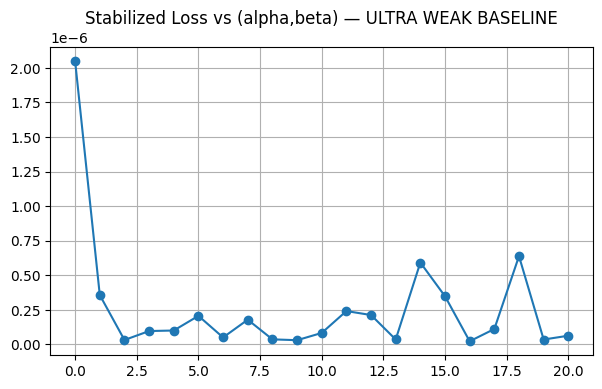

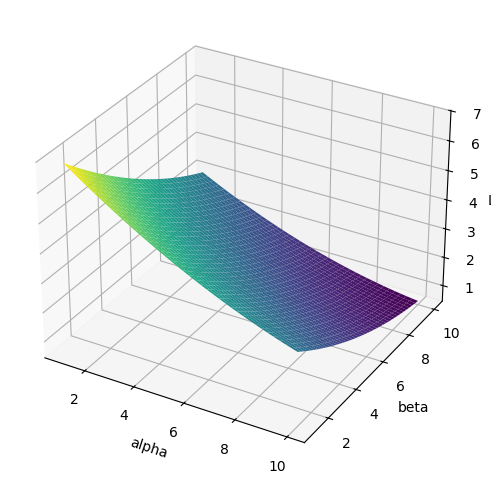

In [ ]:
# ============================================================
# X-SciAL Burgers PINN
# ULTRA-WEAK baseline + repeated adaptive loop until stabilization
# ============================================================

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------------------------------------
# Domain
# ------------------------------------------------------------
x_min,x_max=-1,1
t_min,t_max=0,1
nu=0.01/np.pi

# ------------------------------------------------------------
# ULTRA-WEAK PINN
# ------------------------------------------------------------
class PINN(nn.Module):
    def __init__(self,layers):
        super().__init__()
        self.net=nn.ModuleList()
        for i in range(len(layers)-1):
            self.net.append(nn.Linear(layers[i],layers[i+1]))
    def forward(self,x):
        for layer in self.net[:-1]:
            x=torch.tanh(layer(x))
        return self.net[-1](x)

# ------------------------------------------------------------
# Residual
# ------------------------------------------------------------
def burgers_residual(model,x,t):
    x.requires_grad_(True);t.requires_grad_(True)
    u=model(torch.cat([x,t],1))
    u_t=torch.autograd.grad(u,t,torch.ones_like(u),retain_graph=True,create_graph=True)[0]
    u_x=torch.autograd.grad(u,x,torch.ones_like(u),retain_graph=True,create_graph=True)[0]
    u_xx=torch.autograd.grad(u_x,x,torch.ones_like(u_x),retain_graph=True,create_graph=True)[0]
    return u_t+u*u_x-nu*u_xx

# ------------------------------------------------------------
# VERY WEAK collocation data
# ------------------------------------------------------------
N_f=600
x_f_base=torch.rand(N_f,1)*(x_max-x_min)+x_min
t_f_base=torch.rand(N_f,1)*(t_max-t_min)+t_min
x_f_base,t_f_base=x_f_base.to(device),t_f_base.to(device)

def pinn_loss(model,x_f,t_f):
    return torch.mean(burgers_residual(model,x_f,t_f)**2)

# ------------------------------------------------------------
# Grid for maps
# ------------------------------------------------------------
Nx,Nt=60,60
x=np.linspace(-1,1,Nx)
t=np.linspace(0,1,Nt)
X,T=np.meshgrid(x,t)

x_t=torch.tensor(X.reshape(-1,1),dtype=torch.float32).to(device)
t_t=torch.tensor(T.reshape(-1,1),dtype=torch.float32).to(device)

# ------------------------------------------------------------
# Uncertainty + attribution
# ------------------------------------------------------------
def compute_uncertainty(model,x,t,n=5):
    model.train()
    preds=[]
    with torch.no_grad():
        for _ in range(n):
            preds.append(model(torch.cat([x,t],1)))
    return torch.var(torch.stack(preds),0)

def compute_attr(model,x,t):
    model.eval()
    x.requires_grad_(True);t.requires_grad_(True)
    u=model(torch.cat([x,t],1))
    ux=torch.autograd.grad(u,x,torch.ones_like(u),retain_graph=True,create_graph=True)[0]
    ut=torch.autograd.grad(u,t,torch.ones_like(u),retain_graph=True,create_graph=True)[0]
    return torch.sqrt(ux**2+ut**2)

# ============================================================
# EXPERIMENT
# ============================================================
centers=[(float(i),float(i)) for i in range(0,21)]

loss_list=[]
alpha_list=[]
beta_list=[]

# stabilization parameters
tol=1e-10
max_adaptive_iters=10

for alpha,beta in centers:

    print(f"\nRunning alpha={alpha}, beta={beta}")

    model=PINN([2,16,16,1]).to(device)
    opt=torch.optim.Adam(model.parameters(),lr=1e-3)

    x_f=x_f_base.clone()
    t_f=t_f_base.clone()

    # --- ultra weak baseline training ---
    for epoch in range(400):
        opt.zero_grad()
        pinn_loss(model,x_f,t_f).backward()
        opt.step()

    prev_loss=1e9

    # --- repeated adaptive loop until stabilization ---
    for it in range(max_adaptive_iters):

        U=compute_uncertainty(model,x_t,t_t).cpu().numpy().reshape(Nt,Nx)
        A=compute_attr(model,x_t,t_t).cpu().detach().numpy().reshape(Nt,Nx)

        U_n=(U-U.min())/(U.max()-U.min()+1e-8)
        A_n=(A-A.min())/(A.max()-A.min()+1e-8)
        S=(U_n**alpha)*(A_n**beta)

        # sample
        k=80
        idx=np.argsort(S.flatten())[::-1][:k]
        x_new=X.flatten()[idx][:,None]
        t_new=T.flatten()[idx][:,None]

        x_f=torch.cat([x_f,torch.tensor(x_new,dtype=torch.float32).to(device)])
        t_f=torch.cat([t_f,torch.tensor(t_new,dtype=torch.float32).to(device)])

        # weak retrain
        for _ in range(150):
            opt.zero_grad()
            pinn_loss(model,x_f,t_f).backward()
            opt.step()

        cur_loss=pinn_loss(model,x_f,t_f).item()
        print(f"Iter {it+1} Loss {cur_loss:.4e}")

        if abs(prev_loss-cur_loss)<tol:
            print("Loss stabilized")
            break

        prev_loss=cur_loss

    loss_list.append(cur_loss)
    alpha_list.append(alpha)
    beta_list.append(beta)

# ============================================================
# Plot
# ============================================================
plt.figure(figsize=(7,4))
plt.plot(range(len(loss_list)),loss_list,marker='o')
plt.title("Stabilized Loss vs (alpha,beta) — ULTRA WEAK BASELINE")
plt.grid(True)
plt.show()

# ============================================================
# Surrogate surface
# ============================================================
A=np.array(alpha_list)
B=np.array(beta_list)
L=np.array(loss_list)

X_design=np.vstack([np.ones_like(A),A,B,A*B,A**2,B**2]).T
theta=np.linalg.lstsq(X_design,L,rcond=None)[0]

def L_hat(a,b):
    return theta[0]+theta[1]*a+theta[2]*b+theta[3]*a*b+theta[4]*a*a+theta[5]*b*b

alpha_vals=np.linspace(1,10,40)
beta_vals=np.linspace(1,10,40)
A_grid,B_grid=np.meshgrid(alpha_vals,beta_vals)
Loss_pred=L_hat(A_grid,B_grid)

fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection='3d')
ax.plot_surface(A_grid,B_grid,Loss_pred,cmap='viridis')
ax.set_xlabel("alpha")
ax.set_ylabel("beta")
ax.set_zlabel("Loss")
plt.show()

# Weak Baseline


Running alpha=0.0, beta=0.0
Iter 1 Loss 1.7853e-07
Iter 2 Loss 9.7013e-08
Iter 3 Loss 5.4758e-08
Iter 4 Loss 3.4289e-08
Iter 5 Loss 2.4086e-08
Iter 6 Loss 1.8462e-08
Iter 7 Loss 1.4942e-08
Iter 8 Loss 1.2481e-08
Iter 9 Loss 1.0610e-08
Iter 10 Loss 9.1004e-09

Running alpha=1.0, beta=1.0
Iter 1 Loss 1.3459e-07
Iter 2 Loss 8.4745e-08
Iter 3 Loss 5.3531e-08
Iter 4 Loss 3.6652e-08
Iter 5 Loss 2.8169e-08
Iter 6 Loss 2.3761e-08
Iter 7 Loss 2.2401e-08
Iter 8 Loss 1.9134e-08
Iter 9 Loss 1.7425e-08
Iter 10 Loss 1.5924e-08

Running alpha=2.0, beta=2.0
Iter 1 Loss 6.1050e-08
Iter 2 Loss 6.0713e-06
Iter 3 Loss 2.9633e-08
Iter 4 Loss 1.9793e-08
Iter 5 Loss 1.3118e-08
Iter 6 Loss 8.7513e-09
Iter 7 Loss 4.5061e-06
Iter 8 Loss 3.9672e-09
Iter 9 Loss 2.8999e-09
Iter 10 Loss 2.1057e-09

Running alpha=3.0, beta=3.0
Iter 1 Loss 4.8447e-07
Iter 2 Loss 2.4341e-07
Iter 3 Loss 1.6424e-07
Iter 4 Loss 1.2997e-07
Iter 5 Loss 1.0728e-07
Iter 6 Loss 8.9823e-08
Iter 7 Loss 7.5962e-08
Iter 8 Loss 6.4767e-08
Iter 9 

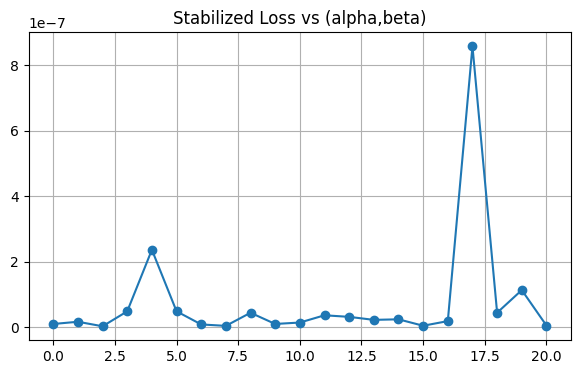

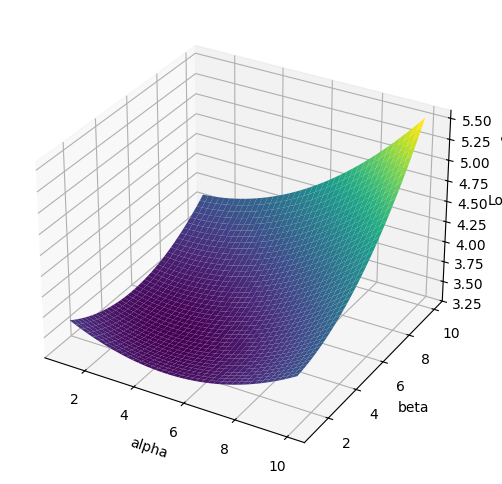

In [ ]:
# ============================================================
# X-SciAL Burgers PINN
# Weak baseline + repeated adaptive loop until stabilization
# Estimate stabilized loss L*(alpha,beta)
# ============================================================

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

torch.manual_seed(0)
np.random.seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------------------------------------
# Domain
# ------------------------------------------------------------
x_min,x_max=-1,1
t_min,t_max=0,1
nu=0.01/np.pi

# ------------------------------------------------------------
# WEAK PINN
# ------------------------------------------------------------
class PINN(nn.Module):
    def __init__(self,layers):
        super().__init__()
        self.net=nn.ModuleList()
        for i in range(len(layers)-1):
            self.net.append(nn.Linear(layers[i],layers[i+1]))
    def forward(self,x):
        for layer in self.net[:-1]:
            x=torch.tanh(layer(x))
        return self.net[-1](x)

# ------------------------------------------------------------
# Residual
# ------------------------------------------------------------
def burgers_residual(model,x,t):
    x.requires_grad_(True);t.requires_grad_(True)
    u=model(torch.cat([x,t],1))
    u_t=torch.autograd.grad(u,t,torch.ones_like(u),retain_graph=True,create_graph=True)[0]
    u_x=torch.autograd.grad(u,x,torch.ones_like(u),retain_graph=True,create_graph=True)[0]
    u_xx=torch.autograd.grad(u_x,x,torch.ones_like(u_x),retain_graph=True,create_graph=True)[0]
    return u_t+u*u_x-nu*u_xx

# ------------------------------------------------------------
# Weak collocation data
# ------------------------------------------------------------
N_f=1200
x_f_base=torch.rand(N_f,1)*(x_max-x_min)+x_min
t_f_base=torch.rand(N_f,1)*(t_max-t_min)+t_min
x_f_base,t_f_base=x_f_base.to(device),t_f_base.to(device)

def pinn_loss(model,x_f,t_f):
    return torch.mean(burgers_residual(model,x_f,t_f)**2)

# ------------------------------------------------------------
# Grid for maps
# ------------------------------------------------------------
Nx,Nt=80,80
x=np.linspace(-1,1,Nx)
t=np.linspace(0,1,Nt)
X,T=np.meshgrid(x,t)

x_t=torch.tensor(X.reshape(-1,1),dtype=torch.float32).to(device)
t_t=torch.tensor(T.reshape(-1,1),dtype=torch.float32).to(device)

# ------------------------------------------------------------
# Uncertainty + attribution
# ------------------------------------------------------------
def compute_uncertainty(model,x,t,n=8):
    model.train()
    preds=[]
    with torch.no_grad():
        for _ in range(n):
            preds.append(model(torch.cat([x,t],1)))
    return torch.var(torch.stack(preds),0)

def compute_attr(model,x,t):
    model.eval()
    x.requires_grad_(True);t.requires_grad_(True)
    u=model(torch.cat([x,t],1))
    ux=torch.autograd.grad(u,x,torch.ones_like(u),retain_graph=True,create_graph=True)[0]
    ut=torch.autograd.grad(u,t,torch.ones_like(u),retain_graph=True,create_graph=True)[0]
    return torch.sqrt(ux**2+ut**2)

# ============================================================
# EXPERIMENT: repeated adaptive loop until stabilization
# ============================================================
centers=[(float(i),float(i)) for i in range(0,21)]

loss_list=[]
alpha_list=[]
beta_list=[]

tol=1e-10
max_adaptive_iters=10

for alpha,beta in centers:

    print(f"\nRunning alpha={alpha}, beta={beta}")

    model=PINN([2,32,32,1]).to(device)
    opt=torch.optim.Adam(model.parameters(),lr=1e-3)

    x_f=x_f_base.clone()
    t_f=t_f_base.clone()

    # --- weak baseline training ---
    for epoch in range(800):
        opt.zero_grad()
        pinn_loss(model,x_f,t_f).backward()
        opt.step()

    prev_loss=1e9

    # --- adaptive loop with stabilization ---
    for it in range(max_adaptive_iters):

        U=compute_uncertainty(model,x_t,t_t).cpu().numpy().reshape(Nt,Nx)
        A=compute_attr(model,x_t,t_t).cpu().detach().numpy().reshape(Nt,Nx)

        U_n=(U-U.min())/(U.max()-U.min()+1e-8)
        A_n=(A-A.min())/(A.max()-A.min()+1e-8)
        S=(U_n**alpha)*(A_n**beta)

        # sample top-k
        k=120
        idx=np.argsort(S.flatten())[::-1][:k]
        x_new=X.flatten()[idx][:,None]
        t_new=T.flatten()[idx][:,None]

        x_f=torch.cat([x_f,torch.tensor(x_new,dtype=torch.float32).to(device)])
        t_f=torch.cat([t_f,torch.tensor(t_new,dtype=torch.float32).to(device)])

        # retrain weakly
        for _ in range(250):
            opt.zero_grad()
            pinn_loss(model,x_f,t_f).backward()
            opt.step()

        cur_loss=pinn_loss(model,x_f,t_f).item()
        print(f"Iter {it+1} Loss {cur_loss:.4e}")

        if abs(prev_loss-cur_loss)<tol:
            print("Loss stabilized")
            break

        prev_loss=cur_loss

    loss_list.append(cur_loss)
    alpha_list.append(alpha)
    beta_list.append(beta)

# ============================================================
# Plot loss vs alpha,beta
# ============================================================
plt.figure(figsize=(7,4))
plt.plot(range(len(loss_list)),loss_list,marker='o')
plt.title("Stabilized Loss vs (alpha,beta)")
plt.grid(True)
plt.show()

# ============================================================
# 3D loss surface surrogate
# ============================================================
A=np.array(alpha_list)
B=np.array(beta_list)
L=np.array(loss_list)

X_design=np.vstack([np.ones_like(A),A,B,A*B,A**2,B**2]).T
theta=np.linalg.lstsq(X_design,L,rcond=None)[0]

def L_hat(a,b):
    return theta[0]+theta[1]*a+theta[2]*b+theta[3]*a*b+theta[4]*a*a+theta[5]*b*b

alpha_vals=np.linspace(1,10,40)
beta_vals=np.linspace(1,10,40)
A_grid,B_grid=np.meshgrid(alpha_vals,beta_vals)
Loss_pred=L_hat(A_grid,B_grid)

fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection='3d')
ax.plot_surface(A_grid,B_grid,Loss_pred,cmap='viridis')
ax.set_xlabel("alpha")
ax.set_ylabel("beta")
ax.set_zlabel("Loss")
plt.show()

# Strong


Running alpha=0.0, beta=0.0
Iter 1 Loss 3.2953e-09
Iter 2 Loss 8.7913e-10
Iter 3 Loss 6.4084e-10
Iter 4 Loss 4.4391e-10
Iter 5 Loss 3.3549e-10
Iter 6 Loss 2.7917e-10
Loss stabilized

Running alpha=1.0, beta=1.0
Iter 1 Loss 3.4126e-09
Iter 2 Loss 3.4340e-10
Iter 3 Loss 4.7021e-07
Iter 4 Loss 1.3172e-10
Iter 5 Loss 1.2030e-10
Loss stabilized

Running alpha=2.0, beta=2.0
Iter 1 Loss 1.2243e-09
Iter 2 Loss 6.3519e-08
Iter 3 Loss 5.3368e-10
Iter 4 Loss 3.4600e-10
Iter 5 Loss 2.8143e-10
Loss stabilized

Running alpha=3.0, beta=3.0
Iter 1 Loss 5.5615e-09
Iter 2 Loss 4.1470e-09
Iter 3 Loss 3.0562e-09
Iter 4 Loss 2.0729e-09
Iter 5 Loss 1.5099e-09
Iter 6 Loss 9.8534e-10
Iter 7 Loss 6.5721e-10
Iter 8 Loss 7.8911e-10
Iter 9 Loss 4.0463e-10
Iter 10 Loss 4.3683e-10
Loss stabilized

Running alpha=4.0, beta=4.0
Iter 1 Loss 2.7437e-09
Iter 2 Loss 1.6470e-09
Iter 3 Loss 1.4919e-09
Iter 4 Loss 1.0157e-09
Iter 5 Loss 7.2271e-10
Iter 6 Loss 4.2581e-10
Iter 7 Loss 3.3822e-10
Loss stabilized

Running alpha=

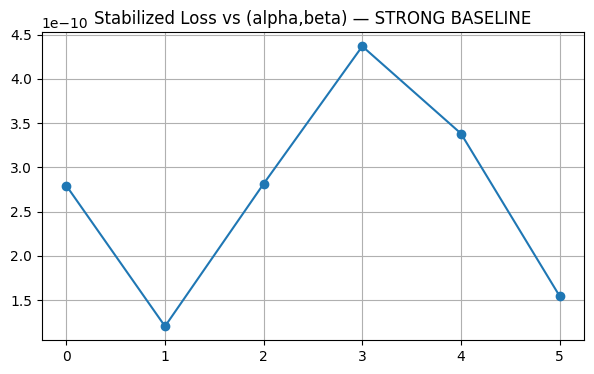

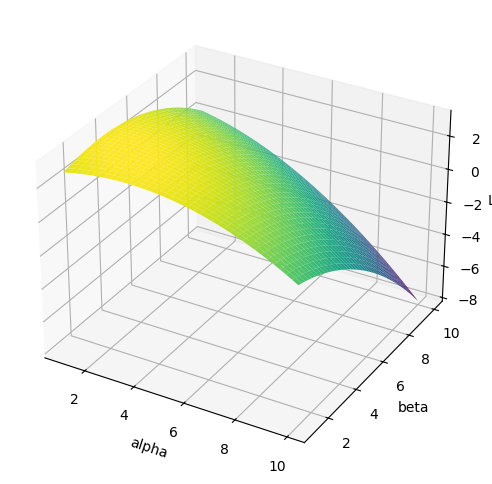

In [ ]:
# ============================================================
# X-SciAL Burgers PINN
# STRONG baseline + repeated adaptive loop until stabilization
# Estimate stabilized loss L*(alpha,beta)
# ============================================================

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

torch.manual_seed(0)
np.random.seed(0)
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------------------------------------
# Domain
# ------------------------------------------------------------
x_min,x_max=-1,1
t_min,t_max=0,1
nu=0.01/np.pi

# ------------------------------------------------------------
# STRONG PINN
# ------------------------------------------------------------
class PINN(nn.Module):
    def __init__(self,layers):
        super().__init__()
        self.net=nn.ModuleList()
        for i in range(len(layers)-1):
            self.net.append(nn.Linear(layers[i],layers[i+1]))
    def forward(self,x):
        for layer in self.net[:-1]:
            x=torch.tanh(layer(x))
        return self.net[-1](x)

# ------------------------------------------------------------
# Residual
# ------------------------------------------------------------
def burgers_residual(model,x,t):
    x.requires_grad_(True);t.requires_grad_(True)
    u=model(torch.cat([x,t],1))
    u_t=torch.autograd.grad(u,t,torch.ones_like(u),retain_graph=True,create_graph=True)[0]
    u_x=torch.autograd.grad(u,x,torch.ones_like(u),retain_graph=True,create_graph=True)[0]
    u_xx=torch.autograd.grad(u_x,x,torch.ones_like(u_x),retain_graph=True,create_graph=True)[0]
    return u_t+u*u_x-nu*u_xx

# ------------------------------------------------------------
# Strong collocation data
# ------------------------------------------------------------
N_f=5000
x_f_base=torch.rand(N_f,1)*(x_max-x_min)+x_min
t_f_base=torch.rand(N_f,1)*(t_max-t_min)+t_min
x_f_base,t_f_base=x_f_base.to(device),t_f_base.to(device)

def pinn_loss(model,x_f,t_f):
    return torch.mean(burgers_residual(model,x_f,t_f)**2)

# ------------------------------------------------------------
# Grid for maps
# ------------------------------------------------------------
Nx,Nt=120,120
x=np.linspace(-1,1,Nx)
t=np.linspace(0,1,Nt)
X,T=np.meshgrid(x,t)

x_t=torch.tensor(X.reshape(-1,1),dtype=torch.float32).to(device)
t_t=torch.tensor(T.reshape(-1,1),dtype=torch.float32).to(device)

# ------------------------------------------------------------
# Uncertainty + attribution
# ------------------------------------------------------------
def compute_uncertainty(model,x,t,n=15):
    model.train()
    preds=[]
    with torch.no_grad():
        for _ in range(n):
            preds.append(model(torch.cat([x,t],1)))
    return torch.var(torch.stack(preds),0)

def compute_attr(model,x,t):
    model.eval()
    x.requires_grad_(True);t.requires_grad_(True)
    u=model(torch.cat([x,t],1))
    ux=torch.autograd.grad(u,x,torch.ones_like(u),retain_graph=True,create_graph=True)[0]
    ut=torch.autograd.grad(u,t,torch.ones_like(u),retain_graph=True,create_graph=True)[0]
    return torch.sqrt(ux**2+ut**2)

# ============================================================
# EXPERIMENT
# ============================================================
centers=[(float(i),float(i)) for i in range(0,6)]

loss_list=[]
alpha_list=[]
beta_list=[]

tol=1e-10
max_adaptive_iters=10

for alpha,beta in centers:

    print(f"\nRunning alpha={alpha}, beta={beta}")

    model=PINN([2,64,64,64,1]).to(device)
    opt=torch.optim.Adam(model.parameters(),lr=1e-3)

    x_f=x_f_base.clone()
    t_f=t_f_base.clone()

    # --- strong baseline training ---
    for epoch in range(3000):
        opt.zero_grad()
        pinn_loss(model,x_f,t_f).backward()
        opt.step()

    prev_loss=1e9

    # --- adaptive loop ---
    for it in range(max_adaptive_iters):

        U=compute_uncertainty(model,x_t,t_t).cpu().numpy().reshape(Nt,Nx)
        A=compute_attr(model,x_t,t_t).cpu().detach().numpy().reshape(Nt,Nx)

        U_n=(U-U.min())/(U.max()-U.min()+1e-8)
        A_n=(A-A.min())/(A.max()-A.min()+1e-8)
        S=(U_n**alpha)*(A_n**beta)

        # sample
        k=200
        idx=np.argsort(S.flatten())[::-1][:k]
        x_new=X.flatten()[idx][:,None]
        t_new=T.flatten()[idx][:,None]

        x_f=torch.cat([x_f,torch.tensor(x_new,dtype=torch.float32).to(device)])
        t_f=torch.cat([t_f,torch.tensor(t_new,dtype=torch.float32).to(device)])

        # strong retrain
        for _ in range(600):
            opt.zero_grad()
            pinn_loss(model,x_f,t_f).backward()
            opt.step()

        cur_loss=pinn_loss(model,x_f,t_f).item()
        print(f"Iter {it+1} Loss {cur_loss:.4e}")

        if abs(prev_loss-cur_loss)<tol:
            print("Loss stabilized")
            break

        prev_loss=cur_loss

    loss_list.append(cur_loss)
    alpha_list.append(alpha)
    beta_list.append(beta)

# ============================================================
# Plot stabilized loss
# ============================================================
plt.figure(figsize=(7,4))
plt.plot(range(len(loss_list)),loss_list,marker='o')
plt.title("Stabilized Loss vs (alpha,beta) — STRONG BASELINE")
plt.grid(True)
plt.show()

# ============================================================
# 3D surrogate surface
# ============================================================
A=np.array(alpha_list)
B=np.array(beta_list)
L=np.array(loss_list)

X_design=np.vstack([np.ones_like(A),A,B,A*B,A**2,B**2]).T
theta=np.linalg.lstsq(X_design,L,rcond=None)[0]

def L_hat(a,b):
    return theta[0]+theta[1]*a+theta[2]*b+theta[3]*a*b+theta[4]*a*a+theta[5]*b*b

alpha_vals=np.linspace(1,10,40)
beta_vals=np.linspace(1,10,40)
A_grid,B_grid=np.meshgrid(alpha_vals,beta_vals)
Loss_pred=L_hat(A_grid,B_grid)

fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection='3d')
ax.plot_surface(A_grid,B_grid,Loss_pred,cmap='viridis')
ax.set_xlabel("alpha")
ax.set_ylabel("beta")
ax.set_zlabel("Loss")
plt.show()

In [ ]:
# ============================================================
# X-SciAL Burgers PINN
# STRONG baseline + repeated adaptive loop until stabilization
# Estimate stabilized loss L*(alpha,beta)
# ============================================================

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

torch.manual_seed(0)
np.random.seed(0)
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------------------------------------
# Domain
# ------------------------------------------------------------
x_min,x_max=-1,1
t_min,t_max=0,1
nu=0.01/np.pi

# ------------------------------------------------------------
# STRONG PINN
# ------------------------------------------------------------
class PINN(nn.Module):
    def __init__(self,layers):
        super().__init__()
        self.net=nn.ModuleList()
        for i in range(len(layers)-1):
            self.net.append(nn.Linear(layers[i],layers[i+1]))
    def forward(self,x):
        for layer in self.net[:-1]:
            x=torch.tanh(layer(x))
        return self.net[-1](x)

# ------------------------------------------------------------
# Residual
# ------------------------------------------------------------
def burgers_residual(model,x,t):
    x.requires_grad_(True);t.requires_grad_(True)
    u=model(torch.cat([x,t],1))
    u_t=torch.autograd.grad(u,t,torch.ones_like(u),retain_graph=True,create_graph=True)[0]
    u_x=torch.autograd.grad(u,x,torch.ones_like(u),retain_graph=True,create_graph=True)[0]
    u_xx=torch.autograd.grad(u_x,x,torch.ones_like(u_x),retain_graph=True,create_graph=True)[0]
    return u_t+u*u_x-nu*u_xx

# ------------------------------------------------------------
# Strong collocation data
# ------------------------------------------------------------
N_f=5000
x_f_base=torch.rand(N_f,1)*(x_max-x_min)+x_min
t_f_base=torch.rand(N_f,1)*(t_max-t_min)+t_min
x_f_base,t_f_base=x_f_base.to(device),t_f_base.to(device)

def pinn_loss(model,x_f,t_f):
    return torch.mean(burgers_residual(model,x_f,t_f)**2)

# ------------------------------------------------------------
# Grid for maps
# ------------------------------------------------------------
Nx,Nt=120,120
x=np.linspace(-1,1,Nx)
t=np.linspace(0,1,Nt)
X,T=np.meshgrid(x,t)

x_t=torch.tensor(X.reshape(-1,1),dtype=torch.float32).to(device)
t_t=torch.tensor(T.reshape(-1,1),dtype=torch.float32).to(device)

# ------------------------------------------------------------
# Uncertainty + attribution
# ------------------------------------------------------------
def compute_uncertainty(model,x,t,n=15):
    model.train()
    preds=[]
    with torch.no_grad():
        for _ in range(n):
            preds.append(model(torch.cat([x,t],1)))
    return torch.var(torch.stack(preds),0)

def compute_attr(model,x,t):
    model.eval()
    x.requires_grad_(True);t.requires_grad_(True)
    u=model(torch.cat([x,t],1))
    ux=torch.autograd.grad(u,x,torch.ones_like(u),retain_graph=True,create_graph=True)[0]
    ut=torch.autograd.grad(u,t,torch.ones_like(u),retain_graph=True,create_graph=True)[0]
    return torch.sqrt(ux**2+ut**2)

# ============================================================
# EXPERIMENT
# ============================================================
centers=[(float(i),float(i)) for i in range(0,6)]

loss_list=[]
alpha_list=[]
beta_list=[]

tol=1e-100
max_adaptive_iters=20

for alpha,beta in centers:

    print(f"\nRunning alpha={alpha}, beta={beta}")

    model=PINN([2,64,64,64,1]).to(device)
    opt=torch.optim.Adam(model.parameters(),lr=1e-3)

    x_f=x_f_base.clone()
    t_f=t_f_base.clone()

    # --- strong baseline training ---
    for epoch in range(3000):
        opt.zero_grad()
        pinn_loss(model,x_f,t_f).backward()
        opt.step()

    prev_loss=1e9

    # --- adaptive loop ---
    for it in range(max_adaptive_iters):

        U=compute_uncertainty(model,x_t,t_t).cpu().numpy().reshape(Nt,Nx)
        A=compute_attr(model,x_t,t_t).cpu().detach().numpy().reshape(Nt,Nx)

        U_n=(U-U.min())/(U.max()-U.min()+1e-8)
        A_n=(A-A.min())/(A.max()-A.min()+1e-8)
        S=(U_n**alpha)*(A_n**beta)

        # sample
        k=200
        idx=np.argsort(S.flatten())[::-1][:k]
        x_new=X.flatten()[idx][:,None]
        t_new=T.flatten()[idx][:,None]

        x_f=torch.cat([x_f,torch.tensor(x_new,dtype=torch.float32).to(device)])
        t_f=torch.cat([t_f,torch.tensor(t_new,dtype=torch.float32).to(device)])

        # strong retrain
        for _ in range(600):
            opt.zero_grad()
            pinn_loss(model,x_f,t_f).backward()
            opt.step()

        cur_loss=pinn_loss(model,x_f,t_f).item()
        print(f"Iter {it+1} Loss {cur_loss:.4e}")

        if abs(prev_loss-cur_loss)<tol:
            print("Loss stabilized")
            break

        prev_loss=cur_loss

    loss_list.append(cur_loss)
    alpha_list.append(alpha)
    beta_list.append(beta)

# ============================================================
# Plot stabilized loss
# ============================================================
plt.figure(figsize=(7,4))
plt.plot(range(len(loss_list)),loss_list,marker='o')
plt.title("Stabilized Loss vs (alpha,beta) — STRONG BASELINE")
plt.grid(True)
plt.show()

# ============================================================
# 3D surrogate surface
# ============================================================
A=np.array(alpha_list)
B=np.array(beta_list)
L=np.array(loss_list)

X_design=np.vstack([np.ones_like(A),A,B,A*B,A**2,B**2]).T
theta=np.linalg.lstsq(X_design,L,rcond=None)[0]

def L_hat(a,b):
    return theta[0]+theta[1]*a+theta[2]*b+theta[3]*a*b+theta[4]*a*a+theta[5]*b*b

alpha_vals=np.linspace(1,10,40)
beta_vals=np.linspace(1,10,40)
A_grid,B_grid=np.meshgrid(alpha_vals,beta_vals)
Loss_pred=L_hat(A_grid,B_grid)

fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection='3d')
ax.plot_surface(A_grid,B_grid,Loss_pred,cmap='viridis')
ax.set_xlabel("alpha")
ax.set_ylabel("beta")
ax.set_zlabel("Loss")
plt.show()


Running alpha=0.0, beta=0.0
Iter 1 Loss 3.2953e-09
Iter 2 Loss 8.7913e-10
Iter 3 Loss 6.4084e-10
Iter 4 Loss 4.4391e-10
Iter 5 Loss 3.3549e-10
Iter 6 Loss 2.7917e-10
Iter 7 Loss 3.2265e-10
Iter 8 Loss 1.6701e-10
Iter 9 Loss 1.7178e-10
Iter 10 Loss 1.6051e-10
Iter 11 Loss 2.1547e-10
Iter 12 Loss 8.2478e-11
Iter 13 Loss 4.3198e-11
Iter 14 Loss 1.0490e-10
Iter 15 Loss 4.9732e-11
Iter 16 Loss 1.4123e-09
Iter 17 Loss 1.6172e-10
Iter 18 Loss 4.4984e-11
Iter 19 Loss 2.9415e-11
Iter 20 Loss 2.2711e-11

Running alpha=1.0, beta=1.0
Iter 1 Loss 3.4126e-09
Iter 2 Loss 3.4340e-10
Iter 3 Loss 4.7021e-07
Iter 4 Loss 1.3172e-10
Iter 5 Loss 1.2030e-10
Iter 6 Loss 1.1304e-10
Iter 7 Loss 4.2825e-10
Iter 8 Loss 1.9210e-10
Iter 9 Loss 1.1042e-10
Iter 10 Loss 6.5096e-11
Iter 11 Loss 4.1944e-11
Iter 12 Loss 1.5098e-10
Iter 13 Loss 7.3489e-10
Iter 14 Loss 3.9335e-10
Iter 15 Loss 2.8712e-10
Iter 16 Loss 1.9884e-10
Iter 17 Loss 1.3218e-10
Iter 18 Loss 8.7150e-11
Iter 19 Loss 5.8564e-11
Iter 20 Loss 4.0062e-11


KeyboardInterrupt: 

# Weakest Baseline

Streaming output truncated to the last 5000 lines.
Iter 39 Loss 2.3678e-07
Iter 40 Loss 2.1746e-07
Iter 41 Loss 2.0184e-07
Iter 42 Loss 1.8918e-07
Iter 43 Loss 1.7886e-07
Iter 44 Loss 1.7035e-07
Iter 45 Loss 1.6324e-07
Iter 46 Loss 1.5719e-07
Iter 47 Loss 1.5191e-07
Iter 48 Loss 1.4719e-07
Iter 49 Loss 1.4288e-07
Iter 50 Loss 1.3884e-07
Iter 51 Loss 1.3499e-07
Iter 52 Loss 1.3125e-07
Iter 53 Loss 1.2759e-07
Iter 54 Loss 1.2397e-07
Iter 55 Loss 1.2037e-07
Iter 56 Loss 1.1677e-07
Iter 57 Loss 1.1316e-07
Iter 58 Loss 1.0955e-07
Iter 59 Loss 1.0594e-07
Iter 60 Loss 1.0231e-07
Iter 61 Loss 9.8697e-08
Iter 62 Loss 9.5090e-08
Iter 63 Loss 9.1503e-08
Iter 64 Loss 8.7948e-08
Iter 65 Loss 8.4439e-08
Iter 66 Loss 8.0992e-08
Iter 67 Loss 7.7621e-08
Iter 68 Loss 7.4344e-08
Iter 69 Loss 7.1177e-08
Iter 70 Loss 6.8138e-08
Iter 71 Loss 6.5242e-08
Iter 72 Loss 6.2501e-08
Iter 73 Loss 5.9927e-08
Iter 74 Loss 5.7524e-08
Iter 75 Loss 5.5294e-08
Iter 76 Loss 5.3238e-08
Iter 77 Loss 5.1347e-08
Iter 78 Loss 

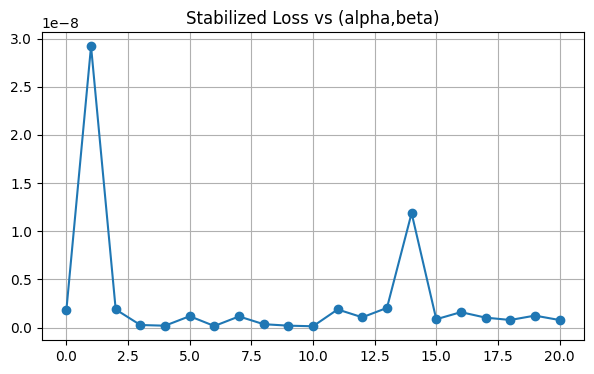

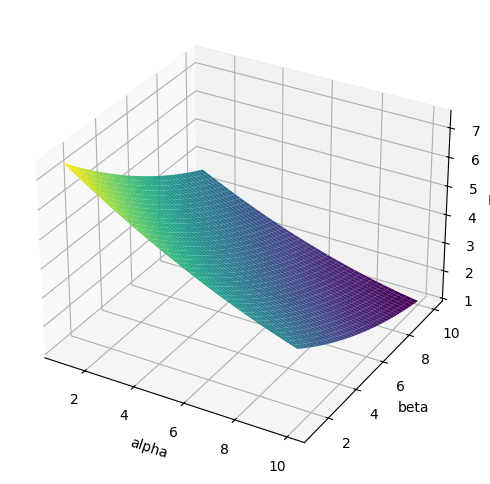

In [ ]:
# ============================================================
# X-SciAL Burgers PINN
# EXTREME WEAK BASELINE
# Repeated adaptive sampling until loss stabilizes
# ============================================================

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

torch.manual_seed(0)
np.random.seed(0)
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------------------------------------
# Domain
# ------------------------------------------------------------
x_min,x_max=-1,1
t_min,t_max=0,1
nu=0.01/np.pi

# ------------------------------------------------------------
# EXTREME WEAK PINN
# ------------------------------------------------------------
class PINN(nn.Module):
    def __init__(self,layers):
        super().__init__()
        self.net=nn.ModuleList()
        for i in range(len(layers)-1):
            self.net.append(nn.Linear(layers[i],layers[i+1]))
    def forward(self,x):
        for layer in self.net[:-1]:
            x=torch.tanh(layer(x))
        return self.net[-1](x)

# ------------------------------------------------------------
# Residual
# ------------------------------------------------------------
def burgers_residual(model,x,t):
    x.requires_grad_(True);t.requires_grad_(True)
    u=model(torch.cat([x,t],1))
    u_t=torch.autograd.grad(u,t,torch.ones_like(u),retain_graph=True,create_graph=True)[0]
    u_x=torch.autograd.grad(u,x,torch.ones_like(u),retain_graph=True,create_graph=True)[0]
    u_xx=torch.autograd.grad(u_x,x,torch.ones_like(u_x),retain_graph=True,create_graph=True)[0]
    return u_t+u*u_x-nu*u_xx

# ------------------------------------------------------------
# VERY FEW collocation points
# ------------------------------------------------------------
N_f=250
x_f_base=torch.rand(N_f,1)*(x_max-x_min)+x_min
t_f_base=torch.rand(N_f,1)*(t_max-t_min)+t_min
x_f_base,t_f_base=x_f_base.to(device),t_f_base.to(device)

def pinn_loss(model,x_f,t_f):
    return torch.mean(burgers_residual(model,x_f,t_f)**2)

# ------------------------------------------------------------
# Coarse grid for maps
# ------------------------------------------------------------
Nx,Nt=40,40
x=np.linspace(-1,1,Nx)
t=np.linspace(0,1,Nt)
X,T=np.meshgrid(x,t)

x_t=torch.tensor(X.reshape(-1,1),dtype=torch.float32).to(device)
t_t=torch.tensor(T.reshape(-1,1),dtype=torch.float32).to(device)

# ------------------------------------------------------------
# Uncertainty + attribution
# ------------------------------------------------------------
def compute_uncertainty(model,x,t,n=3):
    model.train()
    preds=[]
    with torch.no_grad():
        for _ in range(n):
            preds.append(model(torch.cat([x,t],1)))
    return torch.var(torch.stack(preds),0)

def compute_attr(model,x,t):
    model.eval()
    x.requires_grad_(True);t.requires_grad_(True)
    u=model(torch.cat([x,t],1))
    ux=torch.autograd.grad(u,x,torch.ones_like(u),retain_graph=True,create_graph=True)[0]
    ut=torch.autograd.grad(u,t,torch.ones_like(u),retain_graph=True,create_graph=True)[0]
    return torch.sqrt(ux**2+ut**2)

# ============================================================
# EXPERIMENT
# ============================================================
centers=[(float(i),float(i)) for i in range(0,21)]

loss_list=[]
alpha_list=[]
beta_list=[]

# stabilization parameters
tol=1e-20
max_iter=250

for alpha,beta in centers:

    print(f"\nRunning alpha={alpha}, beta={beta}")

    model=PINN([2,8,1]).to(device)
    opt=torch.optim.Adam(model.parameters(),lr=1e-3)

    x_f=x_f_base.clone()
    t_f=t_f_base.clone()

    # --- VERY weak baseline training ---
    for epoch in range(150):
        opt.zero_grad()
        pinn_loss(model,x_f,t_f).backward()
        opt.step()

    prev_loss=1e9

    # --- repeated adaptive sampling ---
    for it in range(max_iter):

        U=compute_uncertainty(model,x_t,t_t).cpu().numpy().reshape(Nt,Nx)
        A=compute_attr(model,x_t,t_t).cpu().detach().numpy().reshape(Nt,Nx)

        U_n=(U-U.min())/(U.max()-U.min()+1e-8)
        A_n=(A-A.min())/(A.max()-A.min()+1e-8)
        S=(U_n**alpha)*(A_n**beta)

        k=50
        idx=np.argsort(S.flatten())[::-1][:k]
        x_new=X.flatten()[idx][:,None]
        t_new=T.flatten()[idx][:,None]

        x_f=torch.cat([x_f,torch.tensor(x_new,dtype=torch.float32).to(device)])
        t_f=torch.cat([t_f,torch.tensor(t_new,dtype=torch.float32).to(device)])

        # retrain
        for _ in range(80):
            opt.zero_grad()
            pinn_loss(model,x_f,t_f).backward()
            opt.step()

        cur_loss=pinn_loss(model,x_f,t_f).item()
        print(f"Iter {it+1} Loss {cur_loss:.4e}")

        if abs(prev_loss-cur_loss)<tol:
            print("Loss stabilized")
            break

        prev_loss=cur_loss

    loss_list.append(cur_loss)
    alpha_list.append(alpha)
    beta_list.append(beta)

# ============================================================
# Plot
# ============================================================
plt.figure(figsize=(7,4))
plt.plot(range(len(loss_list)),loss_list,marker='o')
plt.title("Stabilized Loss vs (alpha,beta)")
plt.grid(True)
plt.show()

# ============================================================
# Surrogate surface
# ============================================================
A=np.array(alpha_list)
B=np.array(beta_list)
L=np.array(loss_list)

X_design=np.vstack([np.ones_like(A),A,B,A*B,A**2,B**2]).T
theta=np.linalg.lstsq(X_design,L,rcond=None)[0]

def L_hat(a,b):
    return theta[0]+theta[1]*a+theta[2]*b+theta[3]*a*b+theta[4]*a*a+theta[5]*b*b

alpha_vals=np.linspace(1,10,40)
beta_vals=np.linspace(1,10,40)
A_grid,B_grid=np.meshgrid(alpha_vals,beta_vals)
Loss_pred=L_hat(A_grid,B_grid)

fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection='3d')
ax.plot_surface(A_grid,B_grid,Loss_pred,cmap='viridis')
ax.set_xlabel("alpha")
ax.set_ylabel("beta")
ax.set_zlabel("Loss")
plt.show()